# RE608 Legged Robot - Week 7: Gait Planning
## Program Studi Teknologi Rekayasa Robotika - Politeknik Negeri Batam

Notebook ini akan mendemonstrasikan bagaimana merencanakan jadwal fase gerak (*gait scheduler*) dan memvisualisasikan diagram *gait* untuk robot berkaki. Kita akan membandingkan berbagai jenis *gait* untuk *quadruped* (Trot, Crawl) dan merancang *Tripod Gait* untuk *Hexapod*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib

# Konfigurasi Google Colab untuk menampilkan animasi matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

print("Environment siap!")

Environment siap!


### 1. Definisi Parameter Gait & Quadruped Scheduler
Sebuah siklus *gait* ditentukan oleh beberapa parameter utama:
- **Stride Period (T):** Waktu yang dibutuhkan untuk menyelesaikan satu siklus penuh.
- **Duty Factor ($\beta$):** Rasio waktu kaki berada di tanah (*stance phase*) dibandingkan dengan total periode siklus.
- **Phase Offset ($\phi$):** Perbedaan waktu mulai siklus antar kaki.

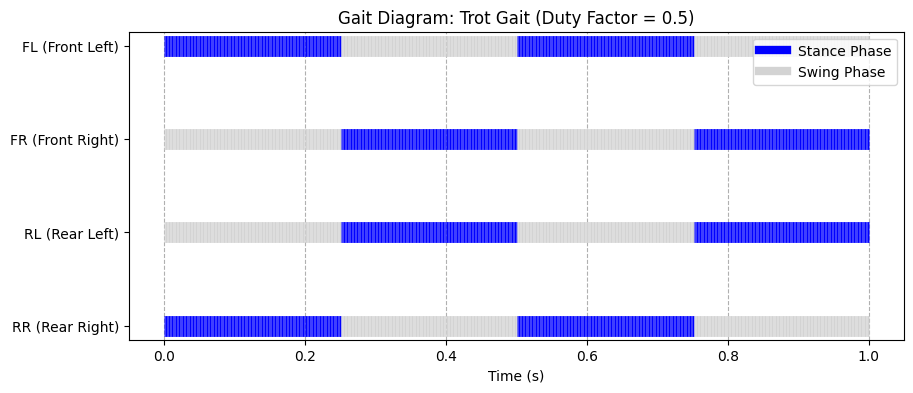

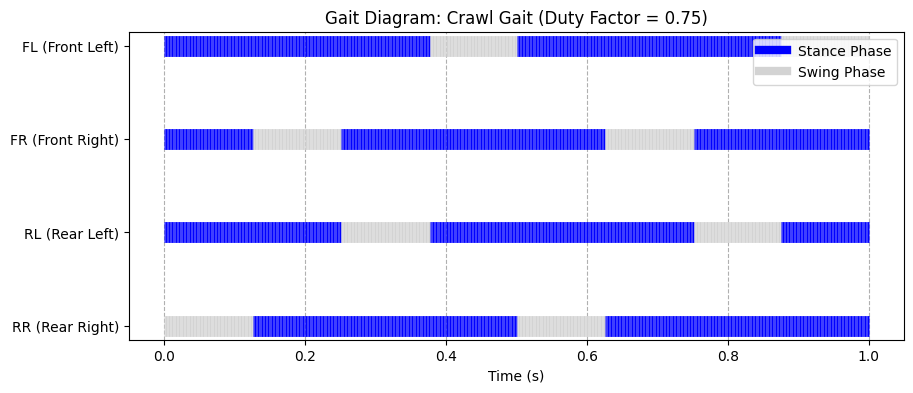

In [2]:
class QuadrupedGaitScheduler:
    def __init__(self, T=1.0):
        self.T = T
        self.legs = ['FL (Front Left)', 'FR (Front Right)', 'RL (Rear Left)', 'RR (Rear Right)']

    def get_phase(self, t, offset):
        # Menghitung fase dari 0.0 hingga 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500) # Plot untuk 2 siklus

        fig, ax = plt.subplots(figsize=(10, 4))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            # Stance (kaki di tanah) = 1, Swing (kaki di udara) = 0
            stance = np.where(phases < duty_factor, 1, 0)

            # Plotting diagram Gantt
            for t_idx in range(len(time_steps)-1):
                if stance[t_idx] == 1:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='blue', lw=15, solid_capstyle='butt')
                else:
                    ax.plot([time_steps[t_idx], time_steps[t_idx+1]], [3-i, 3-i], color='lightgray', lw=15, solid_capstyle='butt')

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        # Legend custom
        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6), plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')

        plt.show()

# Inisialisasi scheduler
scheduler = QuadrupedGaitScheduler(T=0.5)

# 1. Trot Gait: Pasangan diagonal bergerak bersamaan
trot_offsets = [0.0, 0.5, 0.5, 0.0]  # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.5, offsets=trot_offsets, title='Trot Gait')

# 2. Crawl Gait: Gerak bergantian satu per satu, sangat stabil statis
crawl_offsets = [0.0, 0.5, 0.25, 0.75] # [FL, FR, RL, RR]
scheduler.plot_gait_diagram(duty_factor=0.75, offsets=crawl_offsets, title='Crawl Gait')

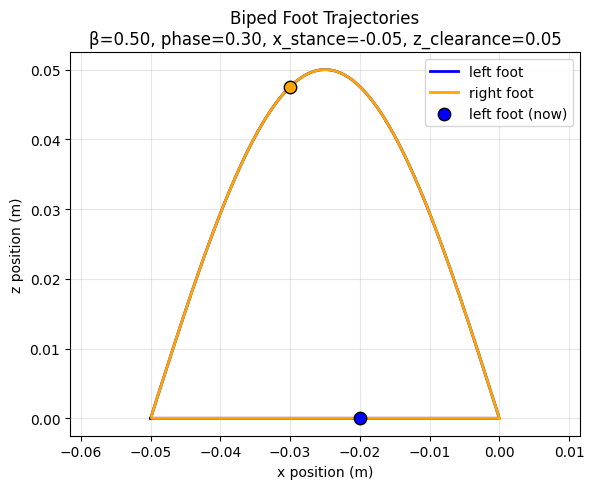

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def foot_position_cmd(phase, beta, x_stance=-0.05, x_lift=0.0,
                      z_ground=0.0, z_clearance=0.05):
    """Return desired (x, z) foot position for leg phase in [0,1)."""
    if phase < beta:  # stance
        t = phase / beta
        x = x_stance + (x_lift - x_stance) * t
        z = z_ground
    else:  # swing
        t = (phase - beta) / (1.0 - beta)
        x = x_lift + (x_stance - x_lift) * t
        z = z_clearance * np.sin(np.pi * t)
    return x, z

# ----- Editable parameters -----
beta = 0.5          # duty factor (stance fraction)
phase = 0.3         # current phase (0..1) to show instantaneous foot positions
x_stance = -0.05    # x position during stance (m)
x_lift = 0.0        # x position at lift-off / touch-down (m)
z_ground = 0.0      # ground height (m)
z_clearance = 0.05  # max foot height during swing (m)
# --------------------------------

T = 1.0  # period of one gait cycle (s)
t = np.linspace(0, T, 400)
phases = t / T  # 0 to 1

# Offsets for left and right foot (opposite phase)
offsets = {'left': 0.0, 'right': 0.5}

plt.figure(figsize=(6,5))
for leg, offset in offsets.items():
    xs, zs = [], []
    for ph in phases:
        x, z = foot_position_cmd((ph + offset) % 1.0,
                                 beta, x_stance, x_lift,
                                 z_ground, z_clearance)
        xs.append(x); zs.append(z)
    color = 'blue' if leg == 'left' else 'orange'
    plt.plot(xs, zs, label=f'{leg} foot', color=color, linewidth=2)

# Instantaneous positions at current phase
cur_xs, cur_zs = [], []
for leg, offset in offsets.items():
    ph_cur = (phase + offset) % 1.0
    x_cur, z_cur = foot_position_cmd(ph_cur, beta,
                                     x_stance, x_lift,
                                     z_ground, z_clearance)
    cur_xs.append(x_cur); cur_zs.append(z_cur)
    color = 'blue' if leg == 'left' else 'orange'
    plt.scatter([x_cur], [z_cur], color=color, s=80, zorder=5,
                edgecolors='k', label=f'{leg} foot (now)' if leg == 'left' else None)

plt.xlabel('x position (m)')
plt.ylabel('z position (m)')
plt.title('Biped Foot Trajectories\n'
          f'β={beta:.2f}, phase={phase:.2f}, x_stance={x_stance:.2f}, '
          f'z_clearance={z_clearance:.2f}')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Assignment: Hexapod Tripod Gait Design

Sesuai materi perkuliahan minggu ini, hexapod dapat menggunakan *tripod gait* di mana 3 kaki membentuk fondasi segitiga yang stabil, secara bergantian (alternating triangles).

**Tugas Praktikum:**
1. Modifikasi kelas/fungsi di atas agar mampu menangani 6 kaki (L1, L2, L3, R1, R2, R3).
2. Buat matriks `offsets` dan tentukan *duty factor* yang tepat untuk *Tripod Gait*.
3. Plot diagram *gait*-nya dan verifikasi kelayakan stabilitasnya.
4. Tuliskan analisis Anda mengenai perbedaan stabilitas antara *Trot Quadruped* dengan *Tripod Hexapod* di sel *markdown* bawah.

---
**Catatan Implementasi Teknis Lanjutan:**
Nantinya saat Anda mengintegrasikan luaran *gait scheduler* ini ke simulasi skrip *forward/inverse kinematics* Anda, pastikan *coxa* dipaksa beroperasi konstan pada bidang XY. Selain itu, Anda harus menghapus keberadaan titik koordinat *base* dari matriks simulasi kakinya. Hal ini akan mencegah perhitungan matriks singular dan mempercepat konvergensi algoritma IK saat transisi fase *stance* ke *swing*.

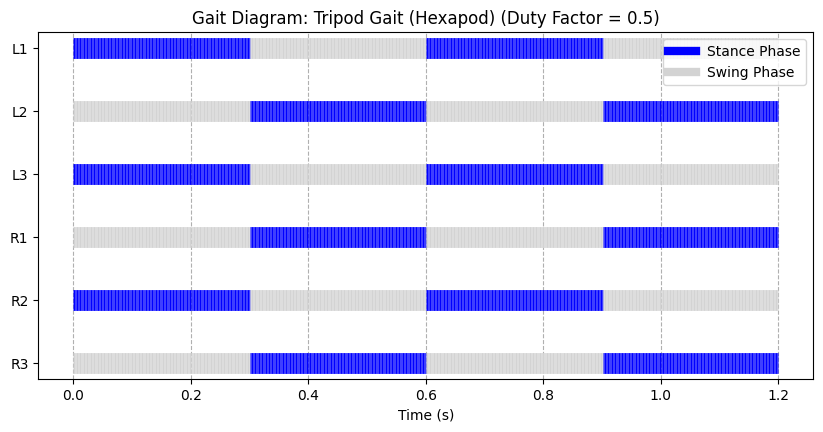

Jumlah kaki menapak (stance) sepanjang siklus -> min: 3, max: 3
VERIFIKASI: Stabil secara statis -- minimal 3 kaki selalu menapak tanah
            di setiap saat, sehingga membentuk poligon topangan (support
            polygon) berbentuk segitiga yang valid sepanjang siklus.


In [4]:
# ============================================================
# TUGAS 1 & 2: Generalisasi Scheduler untuk N Kaki + Tripod Gait
# ============================================================

class LeggedGaitScheduler:
    """
    Versi umum dari QuadrupedGaitScheduler di atas, dimodifikasi agar
    dapat menangani jumlah kaki berapapun (4 untuk quadruped, 6 untuk
    hexapod, dst). Logika get_phase() dan cara menggambar diagram Gantt-nya
    sama persis, hanya labelnya dibuat dinamis sesuai jumlah kaki.
    """
    def __init__(self, legs, T=1.0):
        self.T = T
        self.legs = legs          # daftar nama kaki, mis. ['L1','L2','L3','R1','R2','R3']
        self.n = len(legs)

    def get_phase(self, t, offset):
        # Sama seperti scheduler quadruped: fase berputar dari 0.0 -> 1.0
        return ((t / self.T) + offset) % 1.0

    def plot_gait_diagram(self, duty_factor, offsets, title):
        time_steps = np.linspace(0, 2 * self.T, 500)  # 2 siklus penuh

        fig, ax = plt.subplots(figsize=(10, 4.5))
        for i, (leg, offset) in enumerate(zip(self.legs, offsets)):
            phases = self.get_phase(time_steps, offset)
            stance = np.where(phases < duty_factor, 1, 0)  # 1 = stance, 0 = swing

            for t_idx in range(len(time_steps) - 1):
                color = 'blue' if stance[t_idx] == 1 else 'lightgray'
                ax.plot([time_steps[t_idx], time_steps[t_idx + 1]],
                         [self.n - 1 - i, self.n - 1 - i],
                         color=color, lw=15, solid_capstyle='butt')

        ax.set_yticks(range(self.n))
        ax.set_yticklabels(self.legs[::-1])
        ax.set_xlabel('Time (s)')
        ax.set_title(f'Gait Diagram: {title} (Duty Factor = {duty_factor})')
        ax.grid(axis='x', linestyle='--')

        custom_lines = [plt.Line2D([0], [0], color='blue', lw=6),
                         plt.Line2D([0], [0], color='lightgray', lw=6)]
        ax.legend(custom_lines, ['Stance Phase', 'Swing Phase'], loc='upper right')
        plt.show()

    def stance_count_over_time(self, duty_factor, offsets, n_samples=1000):
        """Hitung berapa kaki yang sedang stance pada setiap titik waktu
        sepanjang satu siklus -- dipakai untuk verifikasi stabilitas statis."""
        time_steps = np.linspace(0, self.T, n_samples, endpoint=False)
        stance_count = np.zeros(n_samples)
        for offset in offsets:
            phases = self.get_phase(time_steps, offset)
            stance_count += (phases < duty_factor).astype(int)
        return time_steps, stance_count


# ----- TUGAS 2: Definisikan kaki & offsets untuk Tripod Gait -----
hexapod_legs = ['L1', 'L2', 'L3', 'R1', 'R2', 'R3']

# Tripod gait: kaki dibagi menjadi 2 grup segitiga yang bergantian menapak.
#   Tripod A = L1, L3, R2   (offset fase 0.0)
#   Tripod B = L2, R1, R3   (offset fase 0.5)
# Urutan offsets HARUS sejajar dengan urutan hexapod_legs di atas.
tripod_offsets = [0.0, 0.5, 0.0,   # L1, L2, L3
                   0.5, 0.0, 0.5]  # R1, R2, R3

# Duty factor 0.5 adalah nilai standar untuk tripod gait: setiap kaki
# menapak tanah (stance) selama tepat separuh siklus, lalu swing di
# separuh sisanya. Dengan dua grup tripod yang saling berkebalikan fase,
# pada SETIAP saat akan selalu ada persis 3 kaki yang stance.
tripod_duty_factor = 0.5

hex_scheduler = LeggedGaitScheduler(legs=hexapod_legs, T=0.6)

# ----- TUGAS 3: Plot diagram gait & verifikasi stabilitas -----
hex_scheduler.plot_gait_diagram(duty_factor=tripod_duty_factor,
                                 offsets=tripod_offsets,
                                 title='Tripod Gait (Hexapod)')

t_check, stance_count = hex_scheduler.stance_count_over_time(tripod_duty_factor, tripod_offsets)
min_legs_on_ground = int(stance_count.min())
max_legs_on_ground = int(stance_count.max())

print(f"Jumlah kaki menapak (stance) sepanjang siklus -> min: {min_legs_on_ground}, max: {max_legs_on_ground}")
if min_legs_on_ground >= 3:
    print("VERIFIKASI: Stabil secara statis -- minimal 3 kaki selalu menapak tanah")
    print("            di setiap saat, sehingga membentuk poligon topangan (support")
    print("            polygon) berbentuk segitiga yang valid sepanjang siklus.")
else:
    print("VERIFIKASI: TIDAK stabil -- ada saat dimana kurang dari 3 kaki menapak tanah.")


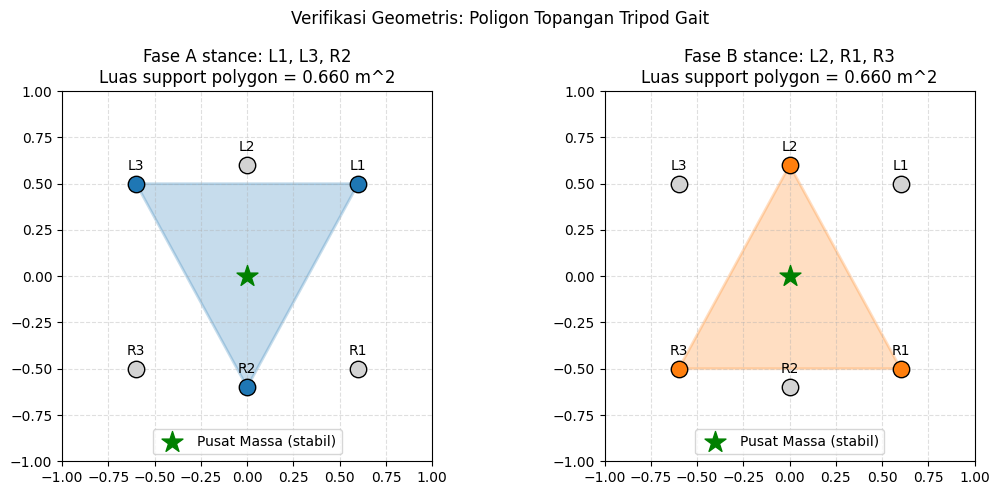

In [5]:
# ============================================================
# Verifikasi tambahan: visualisasi poligon topangan (support polygon)
# Tripod Gait dari sudut pandang atas (top-down view) tubuh hexapod
# ============================================================

from matplotlib.patches import Polygon as MplPolygon
from matplotlib.path import Path as MplPath

# Posisi pemasangan kaki relatif terhadap pusat massa robot (top-down, satuan meter)
leg_positions = {
    'L1': (0.6,  0.5), 'L2': (0.0,  0.6), 'L3': (-0.6,  0.5),
    'R1': (0.6, -0.5), 'R2': (0.0, -0.6), 'R3': (-0.6, -0.5),
}

tripod_A = ['L1', 'L3', 'R2']  # offset 0.0
tripod_B = ['L2', 'R1', 'R3']  # offset 0.5

def support_polygon_area(legs_in_stance):
    pts = np.array([leg_positions[l] for l in legs_in_stance])
    x, y = pts[:, 0], pts[:, 1]
    # Shoelace formula
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def com_inside_polygon(legs_in_stance, com=(0.0, 0.0)):
    pts = [leg_positions[l] for l in legs_in_stance]
    path = MplPath(pts)
    return path.contains_point(com)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, tripod, label, color in zip(
        axes, [tripod_A, tripod_B],
        ['Fase A stance: L1, L3, R2', 'Fase B stance: L2, R1, R3'],
        ['tab:blue', 'tab:orange']):

    # gambar semua kaki
    for leg, (x, y) in leg_positions.items():
        in_stance = leg in tripod
        ax.scatter(x, y, s=140,
                   color=color if in_stance else 'lightgray',
                   edgecolors='k', zorder=3)
        ax.annotate(leg, (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

    # gambar poligon topangan (segitiga)
    pts = [leg_positions[l] for l in tripod]
    poly = MplPolygon(pts, closed=True, facecolor=color, alpha=0.25, edgecolor=color, lw=2)
    ax.add_patch(poly)

    # pusat massa robot diasumsikan di titik (0,0)
    stable = com_inside_polygon(tripod)
    ax.scatter(0, 0, marker='*', s=250, color='red' if not stable else 'green', zorder=4,
              label='Pusat Massa (stabil)' if stable else 'Pusat Massa (TIDAK stabil)')

    area = support_polygon_area(tripod)
    ax.set_title(f'{label}\nLuas support polygon = {area:.3f} m^2')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower center')

plt.suptitle('Verifikasi Geometris: Poligon Topangan Tripod Gait')
plt.tight_layout()
plt.show()


### 3. Analisis: Perbedaan Stabilitas Trot (Quadruped) vs Tripod (Hexapod)

**Trot Gait (Quadruped, duty factor = 0.5):**
Pada *trot gait*, kaki bergerak berpasangan secara diagonal (FL+RR bersama, FR+RL bersama). Karena hanya ada 4 kaki dan duty factor 0.5, pada setiap saat **hanya 2 kaki yang menapak tanah** sekaligus, dan kedua titik tumpuan itu terletak pada satu garis diagonal. Secara geometris, poligon topangan dari 2 titik adalah sebuah **garis lurus berluas nol**, bukan bidang. Akibatnya:
- Trot **tidak stabil secara statis** -- robot tidak bisa berhenti mendadak di sembarang fase siklus tanpa berisiko jatuh, karena pusat massanya tidak selalu berada di dalam area topangan yang valid.
- Trot adalah contoh **dynamically stable gait**: kestabilannya bergantung pada momentum gerak maju dan kontrol aktif (mirip menjaga keseimbangan saat berlari), bukan murni dari geometri kaki yang menapak.
- Keuntungannya: karena hanya separuh kaki yang menapak di setiap saat dan langkahnya lebih panjang, trot bisa mencapai kecepatan jelajah yang lebih tinggi dan lebih efisien energi pada kecepatan tinggi.

**Tripod Gait (Hexapod, duty factor = 0.5):**
Pada *tripod gait*, 6 kaki dibagi menjadi dua grup segitiga (L1,L3,R2 dan L2,R1,R3) yang bergantian menapak. Dengan duty factor 0.5, di setiap saat **selalu ada tepat 3 kaki yang menapak tanah**, dan tiga titik non-kolinear ini membentuk **poligon topangan berbentuk segitiga dengan luas > 0** (terlihat pada hasil verifikasi geometris di atas, dimana pusat massa robot selalu berada di dalam segitiga tersebut). Akibatnya:
- Tripod **stabil secara statis (statically stable)** -- robot secara teori dapat berhenti di fase manapun dalam siklus geraknya dan tetap berdiri tegak tanpa jatuh, tanpa memerlukan kontrol keseimbangan aktif yang rumit.
- Margin stabilitas (jarak dari pusat massa ke tepi terdekat poligon topangan) juga lebih besar dibanding gait dengan 2 kaki tumpu, sehingga lebih toleran terhadap gangguan eksternal (medan tidak rata, dorongan, dsb).
- Trade-off-nya: karena separuh kaki harus selalu menapak (3 dari 6), kecepatan jelajah maksimum tripod gait umumnya lebih rendah dibanding trot pada quadruped dengan ukuran/aktuator yang sebanding, dan konsumsi energi per langkah relatif lebih tinggi karena lebih banyak kaki yang aktif menahan beban tubuh secara bersamaan.

**Kesimpulan:**
Perbedaan mendasar terletak pada jumlah kaki minimum yang diperlukan untuk membentuk *support polygon* berdimensi dua (segitiga, butuh ≥3 titik). Quadruped dengan trot gait secara matematis tidak pernah punya cukup titik tumpu (>2) di saat bersamaan untuk stabil secara statis, sehingga harus mengandalkan dinamika gerak (*dynamic stability*). Hexapod dengan tripod gait selalu memiliki 3 titik tumpu sehingga dapat mencapai *static stability* di sepanjang siklusnya -- ini adalah alasan utama mengapa hexapod dengan tripod gait lebih disukai untuk aplikasi yang mengutamakan keandalan dan kestabilan (misal: medan tidak rata, *inspection robot*, atau saat *payload* tidak boleh berisiko jatuh), sedangkan trot pada quadruped lebih disukai ketika kecepatan dan efisiensi energi pada kecepatan tinggi menjadi prioritas.
